<a href="https://colab.research.google.com/github/ada-xo-xo/dsrp/blob/main/DSRP_2026_Adanna_Oji.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
df = pd.read_csv('/content/nyt_bestsellers_combined (1).csv')
df.head(10)

,year,week,rank,title_id,title,author,pub_year,total_weeks,first_week,debut_rank,best_rank
0,1931,1931-10-12,1,6477,THE TEN COMMANDMENTS,Warwick Deeping,1931,1,1931-10-12,1,1
1,1931,1931-10-12,2,1808,FINCHE'S FORTUNE,Mazo de la Roche,1931,1,1931-10-12,2,2
2,1931,1931-10-12,3,5304,THE GOOD EARTH,Pearl S. Buck,1931,10,1931-10-12,3,1
3,1931,1931-10-12,4,4038,SHADOWS ON THE ROCK,Willa Cather,1931,1,1931-10-12,4,4
4,1931,1931-10-12,5,3946,SCARMOUCHE THE KING MAKER,Rafael Sabatini,1931,1,1931-10-12,5,5
5,1931,1931-11-16,1,2878,MAID IN WAITING,John Galsworthy,1931,9,1931-11-16,1,1
6,1931,1931-11-16,2,7031,TWO PEOPLE,A. A. Milne,1931,4,1931-11-16,2,2
7,1931,1931-11-16,3,413,AMERICAN BEAUTY,Edna Ferber,1931,2,1931-11-16,3,2
8,1931,1931-11-16,4,859,BROOME STAGES,Clemance Dane,1931,3,1931-11-16,4,2
9,1931,1931-11-16,5,4235,SPARKS FLY UPWARD,Oliver LaFarge,1931,1,1931-11-16,5,5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60386 entries, 0 to 60385
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   year         60386 non-null  int64 
 1   week         60386 non-null  object
 2   rank         60386 non-null  int64 
 3   title_id     60386 non-null  int64 
 4   title        60386 non-null  object
 5   author       60376 non-null  object
 6   pub_year     60386 non-null  int64 
 7   total_weeks  60386 non-null  int64 
 8   first_week   60386 non-null  object
 9   debut_rank   60386 non-null  int64 
 10  best_rank    60386 non-null  int64 
dtypes: int64(7), object(4)
memory usage: 5.1+ MB


In [4]:
total_duplicates = df.duplicated().sum()
print("Total duplicate rows:", total_duplicates)

Total duplicate rows: 0


In [5]:
#There is missing data but not sure if I want to remove it because 1: the author seems to be in the title column instead
#2:I won't be focusing on authors and titles at the moment so it won't mess up my data
bool_series = pd.isnull(df["author"])
missing_data = df[bool_series]
print(missing_data)

      year        week  rank  title_id  \
161   1932  1932-11-14     2      3134   
579   1934  1934-08-13     5      2221   
586   1934  1934-08-20     4      2221   
594   1934  1934-08-27     4      2221   
595   1934  1934-08-27     5      1593   
606   1934  1934-09-03     8      2221   
1139  1935  1935-12-16     8      3134   
1739  1937  1937-06-21     7        69   
1754  1937  1937-07-05     7        69   
1847  1937  1937-09-27     6        69   

                                                  title author  pub_year  \
161   MUTINY ON THE BOUNTY, Charles Nordhoff and Jam...    NaN      1932   
579   HOLY DEADLOCK,  by A. P. Herbert. (Doubleday, ...    NaN      1934   
586   HOLY DEADLOCK,  by A. P. Herbert. (Doubleday, ...    NaN      1934   
594   HOLY DEADLOCK,  by A. P. Herbert. (Doubleday, ...    NaN      1934   
595   EAST AND WEST,  by Somerset Maugham. (Doubleda...    NaN      1934   
606   HOLY DEADLOCK,  by A. P. Herbert. (Doubleday, ...    NaN      1934   
1139 

In [6]:
#I wanted to see if each title was only associated with one 1 title ID, however there seems to be multiple editions of the same book under different title ID's.
#I think I will group by title since they are still technically the same book.
title_duplicates = df['title'].duplicated().sum()
print("Total title duplicate rows:", title_duplicates)

title_id_duplicates = df['title_id'].duplicated().sum()
print("Total title ID duplicate rows:", title_id_duplicates)

Total title duplicate rows: 53214
Total title ID duplicate rows: 52955


In [7]:
#Created a 'Start of Decade' column
df['start_of_decade'] = (df['year'] // 10) * 10

#Then converted to string like "1990s" to make a decade column
df['decade'] = df['start_of_decade'].astype(str) + "s"

df

,year,week,rank,title_id,title,author,pub_year,total_weeks,first_week,debut_rank,best_rank,start_of_decade,decade
0,1931,1931-10-12,1,6477,THE TEN COMMANDMENTS,Warwick Deeping,1931,1,1931-10-12,1,1,1930,1930s
1,1931,1931-10-12,2,1808,FINCHE'S FORTUNE,Mazo de la Roche,1931,1,1931-10-12,2,2,1930,1930s
2,1931,1931-10-12,3,5304,THE GOOD EARTH,Pearl S. Buck,1931,10,1931-10-12,3,1,1930,1930s
3,1931,1931-10-12,4,4038,SHADOWS ON THE ROCK,Willa Cather,1931,1,1931-10-12,4,4,1930,1930s
4,1931,1931-10-12,5,3946,SCARMOUCHE THE KING MAKER,Rafael Sabatini,1931,1,1931-10-12,5,5,1930,1930s
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60381,2020,2020-12-06,11,2332,I WOULD LEAVE ME IF I COULD,Halsey,2020,2,2020-11-29,13,2,2020,2020s
60382,2020,2020-12-06,12,6601,THE VANISHING HALF,Brit Bennett,2020,25,2020-06-21,14,1,2020,2020s
60383,2020,2020-12-06,13,7239,WHERE THE CRAWDADS SING,Delia Owens,2018,114,2018-09-23,9,1,2020,2020s
60384,2020,2020-12-06,14,482,ANXIOUS PEOPLE,Fredrik Backman,2020,11,2020-09-27,3,1,2020,2020s


In [8]:
#Since I am focusing on rank and total weeks I don't need to have multiple of the same title
df2 = df.drop_duplicates(subset=['title'])
df2

,year,week,rank,title_id,title,author,pub_year,total_weeks,first_week,debut_rank,best_rank,start_of_decade,decade
0,1931,1931-10-12,1,6477,THE TEN COMMANDMENTS,Warwick Deeping,1931,1,1931-10-12,1,1,1930,1930s
1,1931,1931-10-12,2,1808,FINCHE'S FORTUNE,Mazo de la Roche,1931,1,1931-10-12,2,2,1930,1930s
2,1931,1931-10-12,3,5304,THE GOOD EARTH,Pearl S. Buck,1931,10,1931-10-12,3,1,1930,1930s
3,1931,1931-10-12,4,4038,SHADOWS ON THE ROCK,Willa Cather,1931,1,1931-10-12,4,4,1930,1930s
4,1931,1931-10-12,5,3946,SCARMOUCHE THE KING MAKER,Rafael Sabatini,1931,1,1931-10-12,5,5,1930,1930s
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60371,2020,2020-12-06,1,3793,RHYTHM OF WAR,Brandon Sanderson,2020,1,2020-12-06,11,1,2020,2020s
60372,2020,2020-12-06,2,1317,DAYLIGHT,David Baldacci,2020,1,2020-12-06,12,2,2020,2020s
60376,2020,2020-12-06,6,375,ALL THAT GLITTERS,Danielle Steel,2020,1,2020-12-06,1,6,2020,2020s
60379,2020,2020-12-06,9,6916,TOM CLANCY: SHADOW OF THE DRAGON,Marc Cameron,2020,1,2020-12-06,4,9,2020,2020s


In [9]:
#I will be focusing on decades for the most part so I will remove data from the 2020s beause the dataset doesn't have data for the rest of the decade
df2.drop(df2[df2['start_of_decade'] == 2020].index, inplace=True)
df2

/tmp/ipykernel_30306/2710019767.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.drop(df2[df2['start_of_decade'] == 2020].index, inplace=True)


,year,week,rank,title_id,title,author,pub_year,total_weeks,first_week,debut_rank,best_rank,start_of_decade,decade
0,1931,1931-10-12,1,6477,THE TEN COMMANDMENTS,Warwick Deeping,1931,1,1931-10-12,1,1,1930,1930s
1,1931,1931-10-12,2,1808,FINCHE'S FORTUNE,Mazo de la Roche,1931,1,1931-10-12,2,2,1930,1930s
2,1931,1931-10-12,3,5304,THE GOOD EARTH,Pearl S. Buck,1931,10,1931-10-12,3,1,1930,1930s
3,1931,1931-10-12,4,4038,SHADOWS ON THE ROCK,Willa Cather,1931,1,1931-10-12,4,4,1930,1930s
4,1931,1931-10-12,5,3946,SCARMOUCHE THE KING MAKER,Rafael Sabatini,1931,1,1931-10-12,5,5,1930,1930s
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59590,2019,2019-12-01,15,3303,NOTHING TO SEE HERE,Kevin Wilson,2019,1,2019-12-01,3,15,2010,2010s
59591,2019,2019-12-08,1,166,A MINUTE TO MIDNIGHT,David Baldacci,2019,11,2019-12-08,4,1,2010,2010s
59596,2019,2019-12-08,6,6908,TOM CLANCY: CODE OF HONOR,Marc Cameron,2019,3,2019-12-08,9,6,2010,2010s
59606,2019,2019-12-15,1,6142,THE RISE OF MAGICKS,Nora Roberts,2019,3,2019-12-15,3,1,2010,2010s


In [10]:
#Creating a visualization based on the research question: How has the average total length of time a book stays on the bestseller list changed over the decades?
#Steps: 1. Drop all columns but the total weeks and year.
#2. Group by decade, find mean of weeks
#3. Create scatter plot then go from there

#df2=df.drop(columns=['best_rank','debut_rank','pub_year','author','title','title_id','rank','week'])
df_1930s = df[df["year"] < 1940]
mean_30s= df_1930s['total_weeks'].mean()

df_1940s = df2[df2["year"] .between(1940, 1949)]
mean_40s= df_1940s['total_weeks'].mean()

df_1950s = df2[df2["year"] .between(1950, 1959)]
mean_50s= df_1950s['total_weeks'].mean()

df_1960s = df2[df2["year"] .between(1960, 1969)]
mean_60s= df_1960s['total_weeks'].mean()

df_1970s = df2[df2["year"] .between(1970, 1979)]
mean_70s= df_1970s['total_weeks'].mean()

df_1980s = df2[df2["year"] .between(1980, 1989)]
mean_80s= df_1980s['total_weeks'].mean()

df_1990s = df2[df2["year"] .between(1990, 1999)]
mean_90s= df_1990s['total_weeks'].mean()

df_2000s = df2[df2["year"] .between(2000, 2009)]
mean_00s= df_2000s['total_weeks'].mean()

df_2010s = df2[df2["year"] .between(2010, 2019)]
mean_10s= df_2010s['total_weeks'].mean()

#Will exclude 2020 because the dataset doesn't have data for the rest of the decade

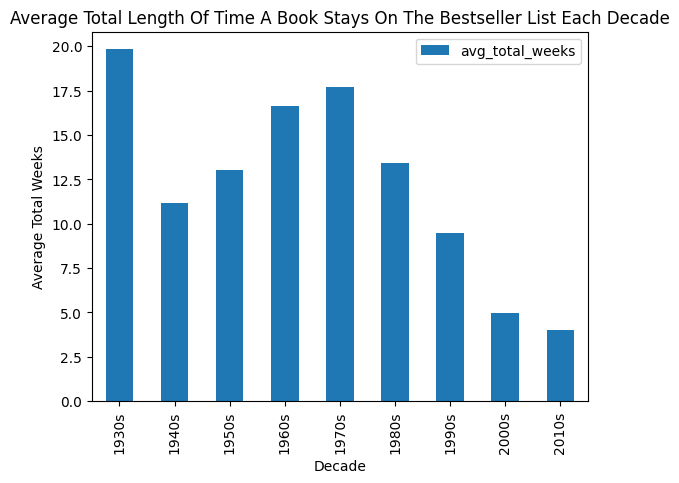

In [11]:
avg_time_per_decade_df = pd.DataFrame({
        "decade": ['1930s','1940s','1950s','1960s','1970s','1980s','1990s','2000s','2010s'],
        "avg_total_weeks": [mean_30s,mean_40s,mean_50s,mean_60s,mean_70s,mean_80s,mean_90s,mean_00s,mean_10s]
     })

avg_time_per_decade_df.plot.bar(x='decade', y='avg_total_weeks')
plt.title('Average Total Length Of Time A Book Stays On The Bestseller List Each Decade')
plt.xlabel('Decade')
plt.ylabel('Average Total Weeks')
plt.show()

In [12]:
#I wanted to check the values
print(avg_time_per_decade_df)

  decade  avg_total_weeks
0  1930s        19.833333
1  1940s        11.193277
2  1950s        13.031153
3  1960s        16.647059
4  1970s        17.699690
5  1980s        13.417699
6  1990s         9.461165
7  2000s         4.958763
8  2010s         4.039184


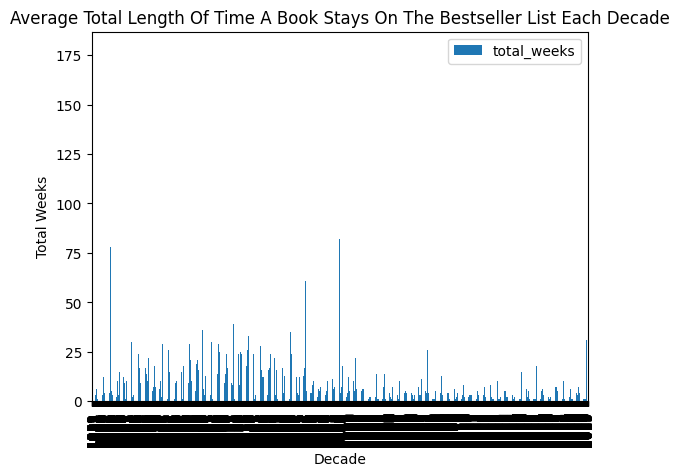

In [13]:
#I wanted to see if the trend was more apparent by year but there is no obvious trend by year
df2.plot.bar(x='year', y='total_weeks')
plt.title('Average Total Length Of Time A Book Stays On The Bestseller List Each Decade')
plt.xlabel('Decade')
plt.ylabel('Total Weeks')
plt.show()

In [14]:
#I am grouping the data, this will help me make more visualizations
avg_rank_df=df2.groupby('decade').mean(numeric_only=True)
avg_rank_df

,year,rank,title_id,pub_year,total_weeks,debut_rank,best_rank,start_of_decade
decade,,,,,,,,
1930s,1935.182482,4.785888,3779.350365,1935.182482,6.479319,4.785888,3.778589,1930.0
1940s,1945.527311,9.726891,3922.304622,1945.527311,11.193277,4.355042,6.907563,1940.0
1950s,1954.352025,13.137072,4073.263240,1954.352025,13.031153,11.252336,9.205607,1950.0
1960s,1963.579832,10.997199,4020.932773,1963.579832,16.647059,9.394958,7.106443,1960.0
1970s,1974.820433,9.414861,4019.978328,1974.820433,17.699690,6.086687,5.510836,1970.0
1980s,1984.838938,10.766372,3731.238938,1984.838938,13.417699,7.053097,6.794690,1980.0
1990s,1994.763350,9.872573,3381.723301,1994.763350,9.461165,8.697816,7.055825,1990.0
2000s,2004.965851,7.612113,3520.920747,2004.965851,4.958763,7.804124,7.126289,2000.0
2010s,2014.374128,7.024691,3715.246377,2014.374128,4.039184,8.320988,6.866881,2010.0


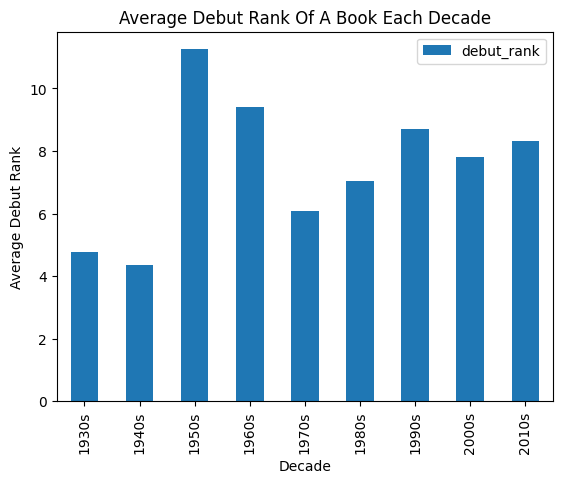

In [15]:
avg_rank_df_reset = avg_rank_df.reset_index()
avg_rank_df_reset.plot.bar(x='decade', y='debut_rank')
plt.title('Average Debut Rank Of A Book Each Decade')
plt.xlabel('Decade')
plt.ylabel('Average Debut Rank')
plt.show()

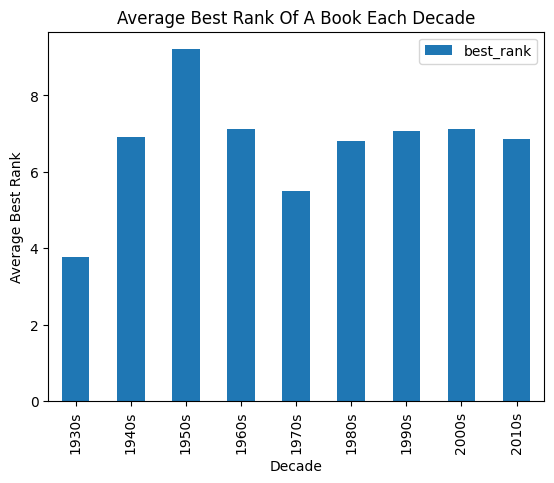

In [16]:
avg_rank_df_reset.plot.bar(x='decade', y='best_rank')
plt.title('Average Best Rank Of A Book Each Decade')
plt.xlabel('Decade')
plt.ylabel('Average Best Rank')
plt.show()

In [17]:
rank1_df=df2[df2['best_rank'] == 1]
grouped_rank1_df=rank1_df.groupby('decade').count()
grouped_rank1_df_reset = grouped_rank1_df.reset_index()
grouped_rank1_df_reset

,decade,year,week,rank,title_id,title,author,pub_year,total_weeks,first_week,debut_rank,best_rank,start_of_decade
0,1930s,74,74,74,74,74,74,74,74,74,74,74,74
1,1940s,59,59,59,59,59,59,59,59,59,59,59,59
2,1950s,34,34,34,34,34,34,34,34,34,34,34,34
3,1960s,31,31,31,31,31,31,31,31,31,31,31,31
4,1970s,46,46,46,46,46,46,46,46,46,46,46,46
5,1980s,76,76,76,76,76,76,76,76,76,76,76,76
6,1990s,98,98,98,98,98,98,98,98,98,98,98,98
7,2000s,211,211,211,211,211,211,211,211,211,211,211,211
8,2010s,280,280,280,280,280,280,280,280,280,280,280,280


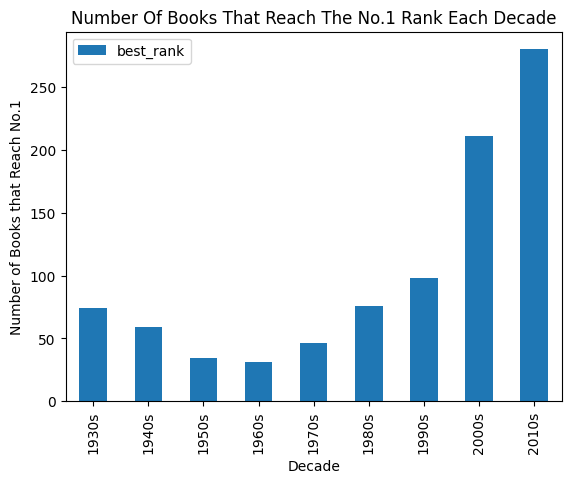

In [18]:
grouped_rank1_df_reset.plot.bar(x='decade', y='best_rank')
plt.title('Number Of Books That Reach The No.1 RankEach Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Books that Reach No.1')
plt.show()

In [41]:
rankcount_1930s_df=df[df['start_of_decade'] == 1930]
rankcount_1930s_df2=rankcount_1930s_df.groupby('rank').count()

rankcount_1940s_df=df[df['start_of_decade'] == 1940]
rankcount_1940s_df2=rankcount_1940s_df.groupby('rank').count()

rankcount_1950s_df=df[df['start_of_decade'] == 1950]
rankcount_1950s_df2=rankcount_1950s_df.groupby('rank').count()

rankcount_1960s_df=df[df['start_of_decade'] == 1960]
rankcount_1960s_df2=rankcount_1960s_df.groupby('rank').count()

rankcount_1970s_df=df[df['start_of_decade'] == 1970]
rankcount_1970s_df2=rankcount_1970s_df.groupby('rank').count()

rankcount_1980s_df=df[df['start_of_decade'] == 1980]
rankcount_1980s_df2=rankcount_1980s_df.groupby('rank').count()

rankcount_1990s_df=df[df['start_of_decade'] == 1990]
rankcount_1990s_df2=rankcount_1990s_df.groupby('rank').count()

rankcount_2000s_df=df[df['start_of_decade'] == 2000]
rankcount_2000s_df2=rankcount_2000s_df.groupby('rank').count()

rankcount_2010s_df=df[df['start_of_decade'] == 2010]
rankcount_2010s_df2=rankcount_2010s_df.groupby('rank').count()

final_rankings_per_decade_df = pd.concat([rankcount_1930s_df2['title'], rankcount_1940s_df2['title'], rankcount_1950s_df2['title'], rankcount_1960s_df2['title'], rankcount_1970s_df2['title'], rankcount_1980s_df2['title'], rankcount_1990s_df2['title'], rankcount_2000s_df2['title'], rankcount_2010s_df2['title']], axis=1)
final_rankings_per_decade_df.columns = ['1930s','1940s','1950s','1960s','1970s','1980s','1990s','2000s','2010s']
#final_rankings_per_decade_df = final_rankings_per_decade_df.reset_index()


final_rankings_per_decade_df

,1930s,1940s,1950s,1960s,1970s,1980s,1990s,2000s,2010s
rank,,,,,,,,,
1,424.0,522.0,519.0,518.0,509.0,522,521.0,519.0,518.0
2,424.0,522.0,519.0,518.0,509.0,522,521.0,519.0,518.0
3,424.0,522.0,519.0,518.0,509.0,522,521.0,519.0,518.0
4,312.0,522.0,519.0,518.0,509.0,522,521.0,519.0,518.0
5,312.0,522.0,519.0,518.0,509.0,522,521.0,519.0,518.0
6,291.0,342.0,519.0,518.0,509.0,522,521.0,519.0,518.0
7,232.0,232.0,519.0,518.0,509.0,522,521.0,519.0,518.0
8,176.0,225.0,519.0,518.0,509.0,522,521.0,519.0,518.0
9,3.0,225.0,519.0,518.0,509.0,522,521.0,519.0,518.0


In [69]:
df_transposed = final_rankings_per_decade_df.transpose()
df_transposed= df_transposed.reset_index()
df_transposed

rank,index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,1930s,424.0,424.0,424.0,312.0,312.0,291.0,232.0,176.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1940s,522.0,522.0,522.0,522.0,522.0,342.0,232.0,225.0,225.0,225.0,225.0,225.0,225.0,225.0,225.0,225.0,NaN,NaN
2,1950s,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,518.0,NaN,NaN
3,1960s,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,161.0,161.0,161.0,161.0,161.0,157.0,NaN,NaN
4,1970s,509.0,509.0,509.0,509.0,509.0,509.0,509.0,509.0,509.0,509.0,108.0,108.0,108.0,108.0,108.0,NaN,NaN,NaN
5,1980s,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,57.0,10.0,1.0
6,1990s,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,95.0,15.0,NaN
7,2000s,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,170.0,1.0,NaN
8,2010s,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,220.0,NaN,NaN


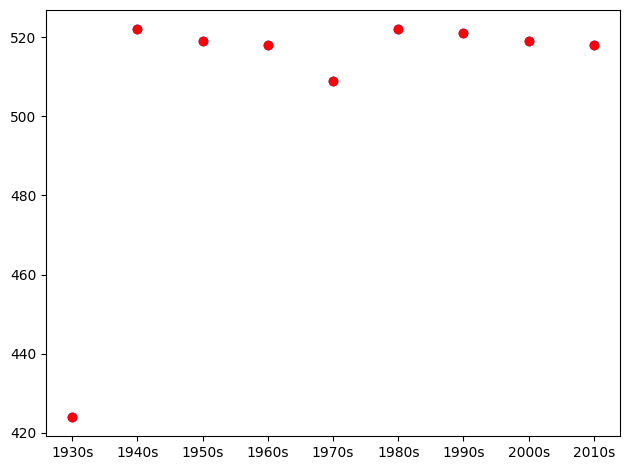

In [72]:
plt.scatter(df_transposed['index'], df_transposed[1], color='blue', label='y1', zorder=1)

plt.scatter(df_transposed['index'], df_transposed[1], color='red', label='y2', zorder=2)

ax.set_title('Number of Books at Each Rank Per Decade')
ax.set_xlabel('Rank')
ax.set_ylabel('Number of Books (Count)')
plt.tight_layout()
plt.show()

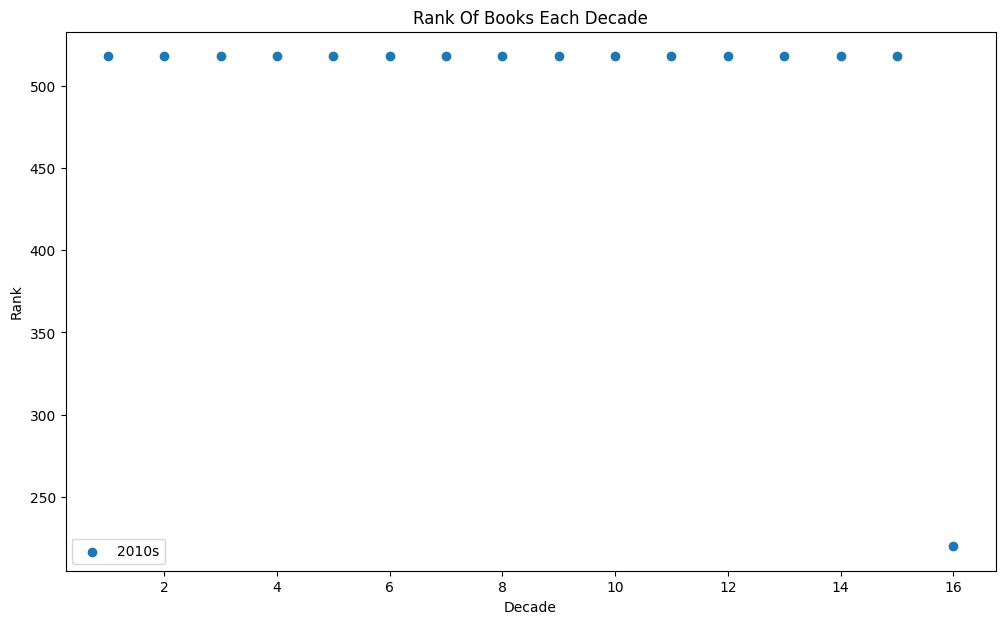

In [38]:

x_decade_labels = ['1930s', '1940s', '1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s']
y_rank_col = 'rank'

# Initialize the plot
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(x=final_rankings_per_decade_df[y_rank_col], y=final_rankings_per_decade_df[decade_col], label=decade_col)

ax.set_title('Number of Books at Each Rank Per Decade')
ax.set_xlabel('Count')
ax.set_ylabel('Decade')
#ax.legend(title='Decade')



#final_rankings_per_decade_df.plot.scatter([x1,x2,x3,x4,x5,x6,x7,x8,x9], y)


#plt.scatter(x1, y, label="1")
#plt.scatter(x2, y, label="2")
#plt.scatter(x3, y, label="3")
#plt.scatter(x4, y, label="4")
#plt.scatter(x5, y, label="5")
#plt.scatter(x6, y, label="6")
#plt.scatter(x7, y, label="7")
#plt.scatter(x8, y, label="8")
#plt.scatter(x9, y, label="9")


plt.title('Rank Of Books Each Decade')
plt.xlabel('Decade')
plt.ylabel('Rank')
plt.legend()
plt.show()

In [ ]:
fesjlsacjabl


rank_per_decade_df = pd.DataFrame({
        "decade": ['1930s','1940s','1950s','1960s','1970s','1980s','1990s','2000s','2010s'],
        "avg_rank": [mean_30s,mean_40s,mean_50s,mean_60s,mean_70s,mean_80s,mean_90s,mean_00s,mean_10s]
     })

df_1930s = df[df["year"] < 1940]
mean_30s= df_1930s['rank'].mean()

df_1940s = df2[df2["year"] .between(1940, 1949)]
mean_40s= df_1940s['rank'].mean()

df_1950s = df2[df2["year"] .between(1950, 1959)]
mean_50s= df_1950s['rank'].mean()

df_1960s = df2[df2["year"] .between(1960, 1969)]
mean_60s= df_1960s['rank'].mean()

df_1970s = df2[df2["year"] .between(1970, 1979)]
mean_70s= df_1970s['total_weeks'].mean()

df_1980s = df2[df2["year"] .between(1980, 1989)]
mean_80s= df_1980s['total_weeks'].mean()

df_1990s = df2[df2["year"] .between(1990, 1999)]
mean_90s= df_1990s['total_weeks'].mean()

df_2000s = df2[df2["year"] .between(2000, 2009)]
mean_00s= df_2000s['total_weeks'].mean()

df_2010s = df2[df2["year"] .between(2010, 2019)]
mean_10s= df_2010s['total_weeks'].mean()


avg_time_per_decade_df.plot.bar(x='decade', y='avg_total_weeks')
plt.title('Average Total Length Of Time A Book Stays On The Bestseller List Each Decade')
plt.xlabel('Decade')
plt.ylabel('Average Total Weeks')
plt.show()